In [205]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [206]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [207]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [208]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [209]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [210]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


On va commencer par un modéle RFM classique:

montant dépensé ;
fréquence d’achat ;
ancienneté du dernier achat.

L'objectif ici est de différencier les gros clients, les clients fréquents et les clients inactifs, mais sans décrire ni la diversité des achats ni leur évolution.

In [211]:
df["montant_total_transaction"] = df["Quantity"] * df["UnitPrice"]

montant_total = df.groupby("CustomerID")["montant_total_transaction"].sum()
montant_total

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: montant_total_transaction, Length: 4338, dtype: float64

In [212]:
data = pd.DataFrame({"montant_total": montant_total})
data

,montant_total
CustomerID,
12346.0,77183.60
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,178.05


In [213]:
from datetime import timedelta

recence = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].max()
    + timedelta(days=1)
).dt.days
data["recence"] = recence
data

,montant_total,recence
CustomerID,,
12346.0,77183.60,326
12347.0,4310.00,2
12348.0,1797.24,75
12349.0,1757.55,19
12350.0,334.40,310
...,...,...
18280.0,180.60,278
18281.0,80.82,181
18282.0,178.05,8


In [214]:
data["frequence"] = df.groupby("CustomerID")["InvoiceNo"].nunique()
data

,montant_total,recence,frequence
CustomerID,,,
12346.0,77183.60,326,1
12347.0,4310.00,2,7
12348.0,1797.24,75,4
12349.0,1757.55,19,1
12350.0,334.40,310,1
...,...,...,...
18280.0,180.60,278,1
18281.0,80.82,181,1
18282.0,178.05,8,2


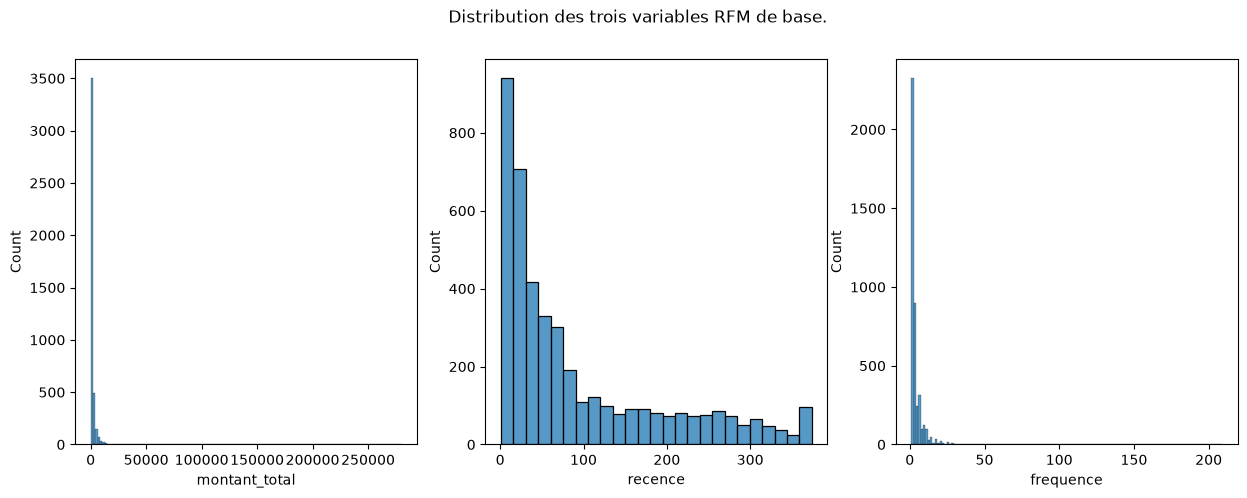

In [215]:
import seaborn as sns

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des trois variables RFM de base.")
sns.histplot(data, x="montant_total", ax=ax[0])
sns.histplot(data, x="recence", ax=ax[1])
sns.histplot(data, x="frequence", ax=ax[2])
plt.show()

On observe que les trois variables ne sont pas centré. On va donc appliqué un logarithme.

In [216]:
import numpy as np

data_log = data.copy()


data_log[data_log.select_dtypes(include="number").columns] = np.log1p(
    data_log[data_log.select_dtypes(include="number").columns]
)
data_log

,montant_total,recence,frequence
CustomerID,,,
12346.0,11.253955,5.789960,0.693147
12347.0,8.368925,1.098612,2.079442
12348.0,7.494564,4.330733,1.609438
12349.0,7.472245,2.995732,0.693147
12350.0,5.815324,5.739793,0.693147
...,...,...,...
18280.0,5.201806,5.631212,0.693147
18281.0,4.404522,5.204007,0.693147
18282.0,5.187665,2.197225,1.098612


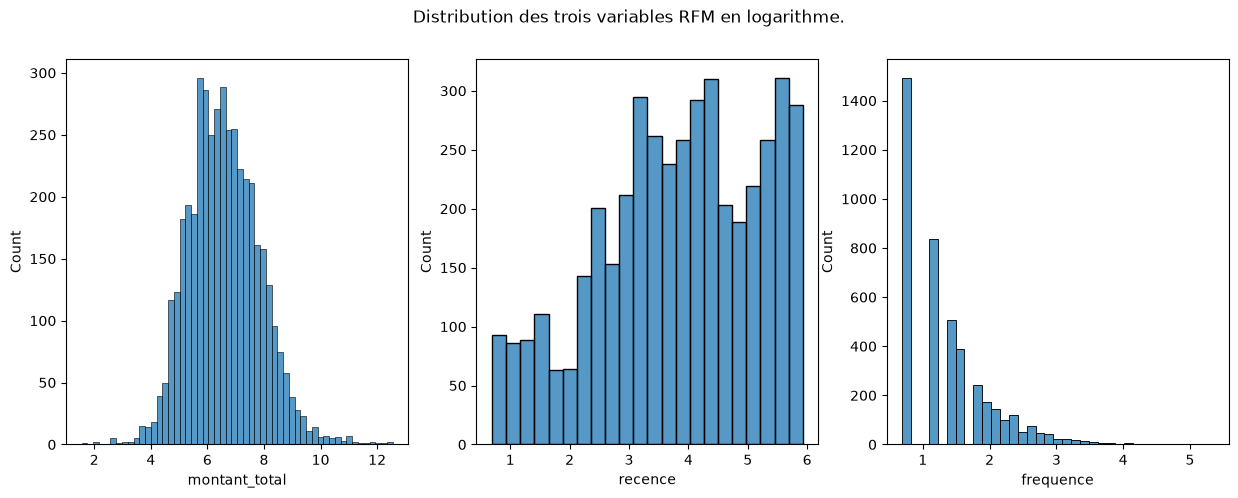

In [217]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des trois variables RFM en logarithme.")
sns.histplot(data_log, x="montant_total", ax=ax[0])
sns.histplot(data_log, x="recence", ax=ax[1])
sns.histplot(data_log, x="frequence", ax=ax[2])
plt.show()

Les trois variables sont maintenant centré. Maintenant on va regardé la surface 3D pour voir si il y a des clusters.

In [218]:
import plotly.express as px

fig = px.scatter_3d(data_log, x="montant_total", y="recence", z="frequence")
fig.update_traces(marker_size=2)
fig.show()

On ne voit aucun cluster distinct. On va donc devoir rajouter de l'information. 

On va ajouter une mesure de diversité et une mesure de dynamique :

Bloc	Variables
Valeur	CA_total
Fréquence	nb_total_commandes
Temps	recency
Assortiment	nb_produits_distincts
Dynamique	ratio_activite_recente_historique

Ce niveau est déjà plus intéressant que le RFM seul, car il distingue :

les clients spécialisés des clients diversifiés ;
les clients dont l’activité augmente ou diminue.


In [219]:
data["nb_produits_distincts"] = df.groupby("CustomerID")["StockCode"].nunique()
data

,montant_total,recence,frequence,nb_produits_distincts
CustomerID,,,,
12346.0,77183.60,326,1,1
12347.0,4310.00,2,7,103
12348.0,1797.24,75,4,22
12349.0,1757.55,19,1,73
12350.0,334.40,310,1,17
...,...,...,...,...
18280.0,180.60,278,1,10
18281.0,80.82,181,1,7
18282.0,178.05,8,2,12


In [220]:
date_fin = df["InvoiceDate"].max()
date_debut_recente = date_fin - pd.Timedelta(days=90)
date_debut_historique = df["InvoiceDate"].min()

duree_recente = 90
duree_historique = (date_debut_recente - date_debut_historique).days

if duree_historique <= 0:
    raise ValueError("La période historique est trop courte.")

clients = pd.Index(df["CustomerID"].unique(), name="CustomerID")

ca_recent = (
    df.loc[df["InvoiceDate"] >= date_debut_recente]
    .groupby("CustomerID")["montant_total_transaction"]
    .sum()
    .reindex(clients, fill_value=0)
)

ca_historique = (
    df.loc[df["InvoiceDate"] < date_debut_recente]
    .groupby("CustomerID")["montant_total_transaction"]
    .sum()
    .reindex(clients, fill_value=0)
)

ca_recent_par_jour = ca_recent / duree_recente
ca_historique_par_jour = ca_historique / duree_historique

ratio_ca_recent_historique = (
    ca_recent_par_jour.div(ca_historique_par_jour)
    .replace([np.inf, -np.inf], np.nan)
    .rename("ratio_ca_recent_historique")
)

data["ratio_activite_recente_historique"] = ratio_ca_recent_historique
data = data.fillna(0)
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique
CustomerID,,,,,
12346.0,77183.60,326,1,1,0.000000
12347.0,4310.00,2,7,103,1.711606
12348.0,1797.24,75,4,22,0.655427
12349.0,1757.55,19,1,73,0.000000
12350.0,334.40,310,1,17,0.000000
...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000
18281.0,80.82,181,1,7,0.000000
18282.0,178.05,8,2,12,2.442506


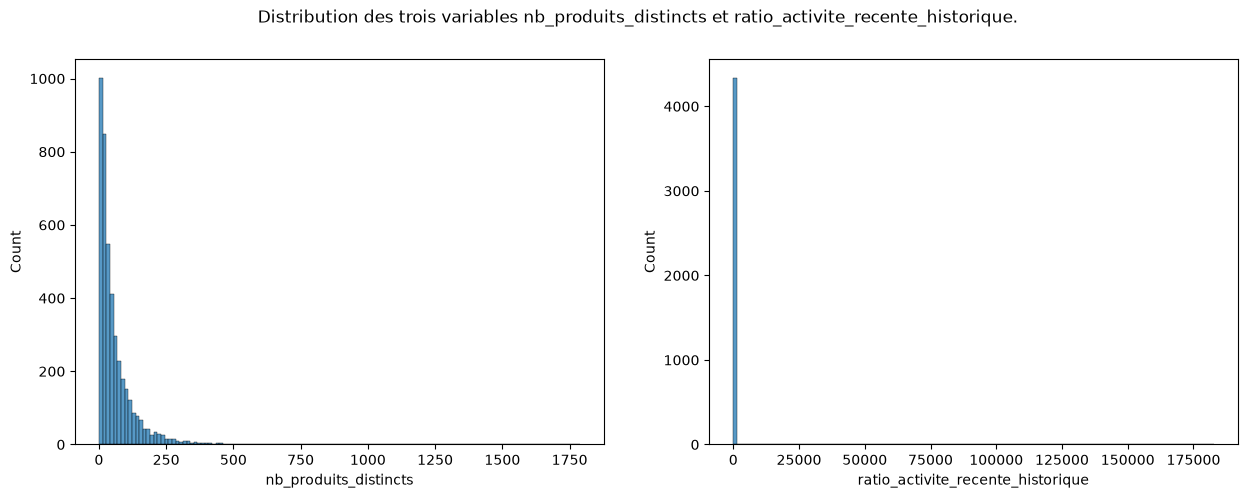

In [221]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(15, 5)
plt.suptitle(
    "Distribution des trois variables nb_produits_distincts et ratio_activite_recente_historique."
)
sns.histplot(data, x="nb_produits_distincts", ax=ax[0])
sns.histplot(data, x="ratio_activite_recente_historique", ax=ax[1])
plt.show()

Là aussi il y a des distribution non centré. Appliquon un logarithme.

In [222]:
data_log = data.copy()


data_log[data_log.select_dtypes(include="number").columns] = np.log1p(
    data_log[data_log.select_dtypes(include="number").columns]
)
data_log

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique
CustomerID,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000
...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200


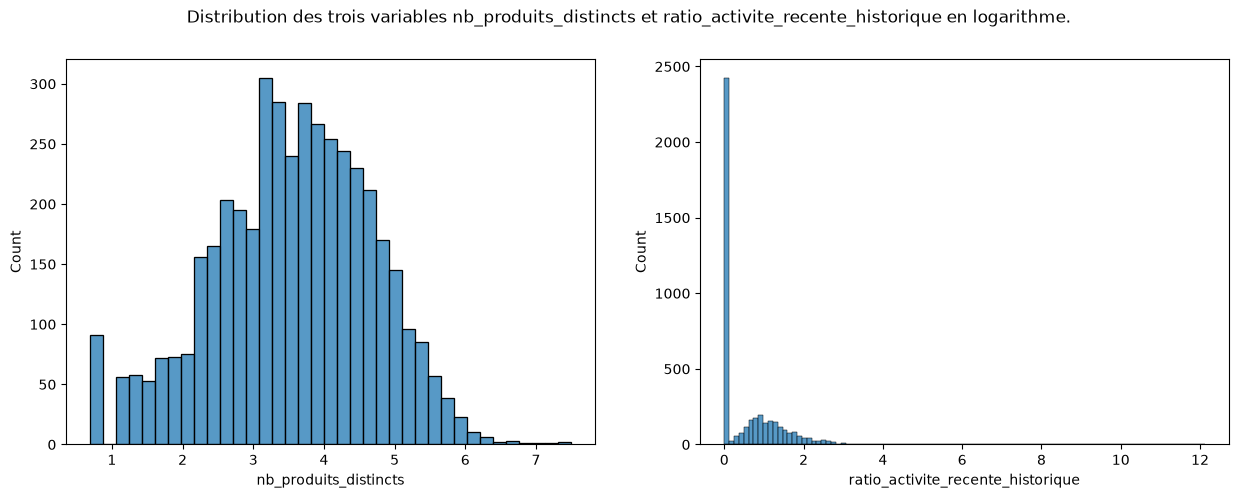

In [223]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(15, 5)
plt.suptitle(
    "Distribution des trois variables nb_produits_distincts et ratio_activite_recente_historique en logarithme."
)
sns.histplot(data_log, x="nb_produits_distincts", ax=ax[0])
sns.histplot(data_log, x="ratio_activite_recente_historique", ax=ax[1])
plt.show()

Le nombre de produit distinct est maintenant centré mais le ration est toujours non centré mais on observe une distribution gaussienne qui se détache de la valeur 0.

<Axes: xlabel='ratio_activite_recente_historique', ylabel='Count'>

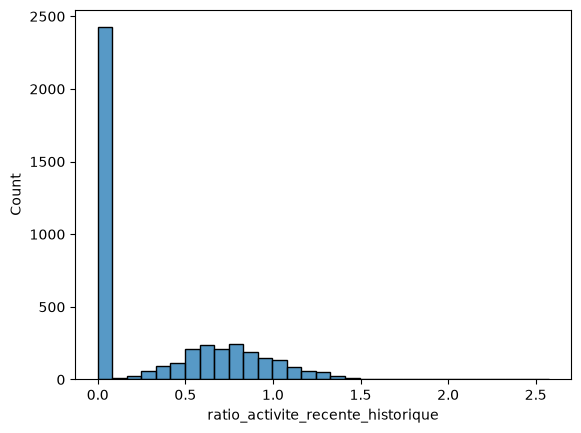

In [224]:
data_log["ratio_activite_recente_historique"] = np.log1p(
    data_log["ratio_activite_recente_historique"]
)
sns.histplot(data_log, x="ratio_activite_recente_historique")

En réappliqaunt un logarithme, on arrive à recentrer la distribution. Appliquon maintenant un PCA.

In [225]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import set_config

set_config(transform_output="pandas")
data_standard = StandardScaler().fit_transform(data_log)
data_standard

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique
CustomerID,,,,,
12346.0,3.706225,1.461993,-0.955214,-2.526376,-0.800804
12347.0,1.411843,-2.038734,1.074425,0.965881,0.837664
12348.0,0.716489,0.373104,0.386304,-0.367738,0.165742
12349.0,0.698739,-0.623086,-0.955214,0.665088,-0.800804
12350.0,-0.618962,1.424558,-0.955214,-0.584387,-0.800804
...,...,...,...,...,...
18280.0,-1.106875,1.343533,-0.955214,-1.019656,-0.800804
18281.0,-1.740933,1.024749,-0.955214,-1.301117,-0.800804
18282.0,-1.118121,-1.218940,-0.361583,-0.872007,1.104921


In [226]:
data_pca = PCA(random_state=42, n_components=3).fit_transform(data_standard)
data_pca

,pca0,pca1,pca2
CustomerID,,,
12346.0,-0.708413,-1.433806,0.455662
12347.0,2.809627,0.453553,-0.830714
12348.0,0.288719,-0.280188,0.345862
12349.0,0.097370,-0.540691,-0.859459
12350.0,-1.931765,-0.591120,0.463476
...,...,...,...
18280.0,-2.327477,-0.175718,0.355517
18281.0,-2.628749,0.356103,0.085989
18282.0,-0.166357,2.171955,-0.188886


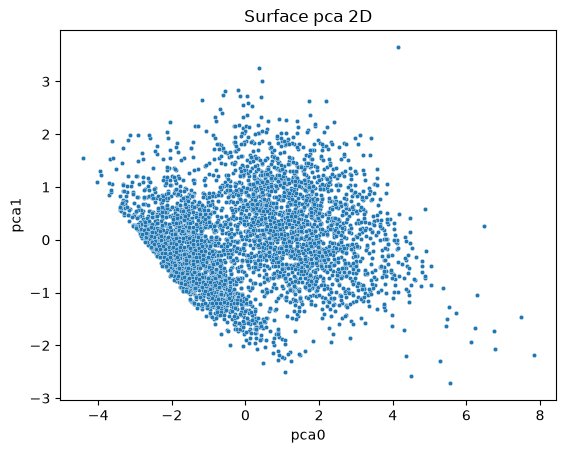

In [227]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10)
plt.title("Surface pca 2D")
plt.show()

In [228]:
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2")
fig.update_traces(marker_size=2)
fig.show()

In [229]:
from sklearn.cluster import KMeans, SpectralClustering

cluster = KMeans(n_clusters=2, random_state=42).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster)
fig.update_traces(marker_size=2)
fig.show()

In [230]:
cluster_spectral = SpectralClustering(
    n_clusters=2, random_state=42, gamma=10
).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster_spectral)
fig.update_traces(marker_size=2)
fig.show()

On peut distinguer sur le graphique 3D 2 cluster différent. Un nuage de points puis un plan. On observe que la méthode Kmeans n'arrive pas à séparer les deux cluster correctement mais le spectralclustering arrive à trouver les deux clusters. Pour essayer d'avoir le troisiéme cluster, il faut donc rajouter plus d'information.

On ajoute la valeur d’une commande, l’ancienneté et la diversité habituelle des paniers :

Bloc	Variables
Valeur	CA_total, nb_total_commandes, panier_moyen
Temps	recency, anciennete_client
Panier	nb_refs_distinctes_moy_par_panier
Assortiment	nb_produits_distincts
Dynamique	ratio_activite_recente_historique

Ce niveau permet de distinguer, par exemple :

un client ancien d’un nouveau client ;
un client fréquent avec de petits paniers d’un client rare avec de gros paniers ;
un client achetant beaucoup de références par commande d’un client faisant des paniers ciblés.

In [231]:
data["ancienneté"] = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].min()
    + timedelta(days=1)
).dt.days
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté
CustomerID,,,,,,
12346.0,77183.60,326,1,1,0.000000,326
12347.0,4310.00,2,7,103,1.711606,367
12348.0,1797.24,75,4,22,0.655427,358
12349.0,1757.55,19,1,73,0.000000,19
12350.0,334.40,310,1,17,0.000000,310
...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278
18281.0,80.82,181,1,7,0.000000,181
18282.0,178.05,8,2,12,2.442506,126


In [232]:
data["panier_moyen"] = data["montant_total"] / data["frequence"]
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen
CustomerID,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000
12347.0,4310.00,2,7,103,1.711606,367,615.714286
12348.0,1797.24,75,4,22,0.655427,358,449.310000
12349.0,1757.55,19,1,73,0.000000,19,1757.550000
12350.0,334.40,310,1,17,0.000000,310,334.400000
...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000
18281.0,80.82,181,1,7,0.000000,181,80.820000
18282.0,178.05,8,2,12,2.442506,126,89.025000


In [233]:
data["nb_refs_distinctes_moy_par_panier"] = (
    df.groupby(["CustomerID", "InvoiceNo"])["StockCode"]
    .nunique()
    .groupby("CustomerID")
    .sum()
    / data["frequence"]
)
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier
CustomerID,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000
...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000


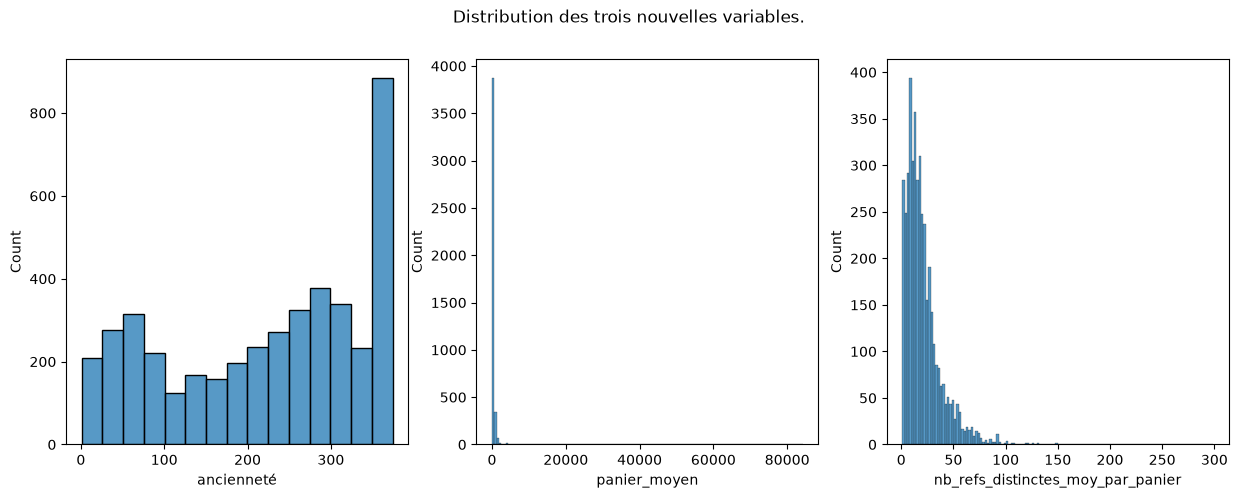

In [234]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des trois nouvelles variables.")
sns.histplot(data, x="ancienneté", ax=ax[0])
sns.histplot(data, x="panier_moyen", ax=ax[1])
sns.histplot(data, x="nb_refs_distinctes_moy_par_panier", ax=ax[2])
plt.show()

Seul l'ancienneté est centré. Appliquons le log sur tous le  dataset sauf sur l'anciennté.

In [235]:
data_log = data.copy()


data_log[
    data_log.select_dtypes(include="number").columns.difference(["ancienneté"])
] = np.log1p(
    data_log[
        data_log.select_dtypes(include="number").columns.difference(["ancienneté"])
    ]
)
data_log

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier
CustomerID,,,,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000,326,11.253955,0.693147
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541,367,6.424406,3.295837
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059,358,6.109936,2.047693
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000,19,7.472245,4.304065
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000,310,5.815324,2.890372
...,...,...,...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000,278,5.201806,2.397895
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000,181,4.404522,2.079442
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200,126,4.500087,1.945910


In [236]:
data_log["ratio_activite_recente_historique"] = np.log1p(
    data_log["ratio_activite_recente_historique"]
)

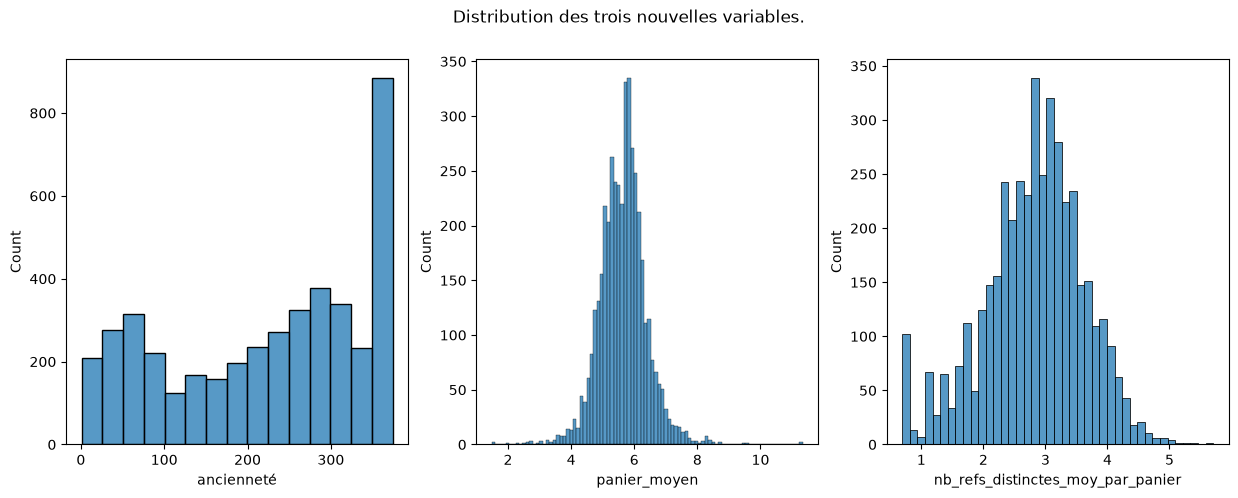

In [237]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des trois nouvelles variables.")
sns.histplot(data_log, x="ancienneté", ax=ax[0])
sns.histplot(data_log, x="panier_moyen", ax=ax[1])
sns.histplot(data_log, x="nb_refs_distinctes_moy_par_panier", ax=ax[2])
plt.show()

Les deux trois nouvelles variables sont maintenant centré.

In [238]:
data_pca = PCA(n_components=0.95, random_state=42).fit_transform(
    StandardScaler().fit_transform(data_log)
)
data_pca

,pca0,pca1,pca2,pca3,pca4
CustomerID,,,,,
12346.0,1.121820,1.529194,3.805407,8.083500,2.006839
12347.0,3.179461,-0.350895,-0.274456,0.331984,-0.034455
12348.0,0.453455,-0.970569,1.198235,0.948964,0.181479
12349.0,0.928331,3.504125,-0.759476,1.181547,0.155130
12350.0,-1.433669,0.510237,1.555981,-0.114951,0.256574
...,...,...,...,...,...
18280.0,-2.273971,-0.225744,1.061475,-0.280475,0.117909
18281.0,-3.172349,-0.721512,-0.029525,-0.671899,-0.151953
18282.0,-1.190236,-1.599606,-2.104210,-0.430693,0.679480


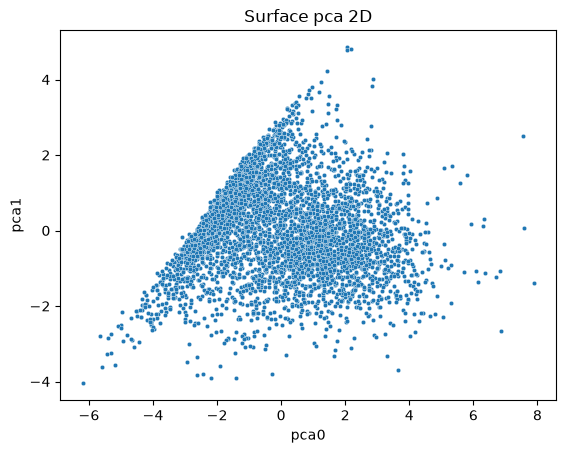

In [239]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10)
plt.title("Surface pca 2D")
plt.show()

In [240]:
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2")
fig.update_traces(marker_size=2)
fig.show()

On a maintenant fussionnée les deux groupes trouvé précédemment mais on commence à avoir une petite séparation de trois clusters. Il faut donc rajouter de l'information.

On complète avec le volume, le rythme d’achat et la concentration des produits :

Bloc	Variables ajoutées
Valeur	quantite_totale_achetee
Temps	intervalle_inter_achat_median
Assortiment	entropie_produit, part_ca_top1

C’est un niveau généralement suffisant pour obtenir une segmentation riche, tout en restant relativement simple à interpréter.

In [241]:
data["quantite_totale_achetee"] = df.groupby("CustomerID")["Quantity"].sum()
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee
CustomerID,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197
...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103


In [242]:
# Une date par commande
dates_commandes = (
    df.groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"]
    .min()
    .reset_index()
    .sort_values(["CustomerID", "InvoiceDate"])
)

# Intervalle entre deux commandes successives
dates_commandes["intervalle_inter_achat"] = (
    dates_commandes.groupby("CustomerID")["InvoiceDate"].diff().dt.days
)

data["intervalle_inter_achat_median"] = (
    dates_commandes.groupby("CustomerID")["intervalle_inter_achat"]
    .median()
    .rename("intervalle_inter_achat_median")
)
data.fillna(0, inplace=True)
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median
CustomerID,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0
...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0


In [243]:
# CA généré par chaque produit pour chaque client
ca_par_produit = df.groupby(["CustomerID", "StockCode"])[
    "montant_total_transaction"
].sum()

# Part de chaque produit dans le CA total du client
part_ca_produit = ca_par_produit / ca_par_produit.groupby(level="CustomerID").transform(
    "sum"
)

nb_produits = ca_par_produit.groupby(level="CustomerID").size()

entropie_produit = (
    -(part_ca_produit * np.log(part_ca_produit))
    .groupby(level="CustomerID")
    .sum()
    .rename("entropie_produit")
)

data["entropie_produit"] = (
    entropie_produit.div(np.log(nb_produits))
    .where(nb_produits > 1, 0)
    .rename("entropie_produit_normalisee")
)

data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit
CustomerID,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473
...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720


In [244]:
ca_par_produit = (
    df.groupby(["CustomerID", "StockCode"])["montant_total_transaction"]
    .sum()
    .rename("ca_produit")
)

part_ca_produit = ca_par_produit / ca_par_produit.groupby("CustomerID").transform("sum")

data["part_ca_top1"] = (
    part_ca_produit.groupby("CustomerID").max().rename("part_ca_top1")
)

data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1
CustomerID,,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000,1.000000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097,0.086241
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004,0.200307
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391,0.170692
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473,0.119617
...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384,0.131229
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080,0.209725
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720,0.143218


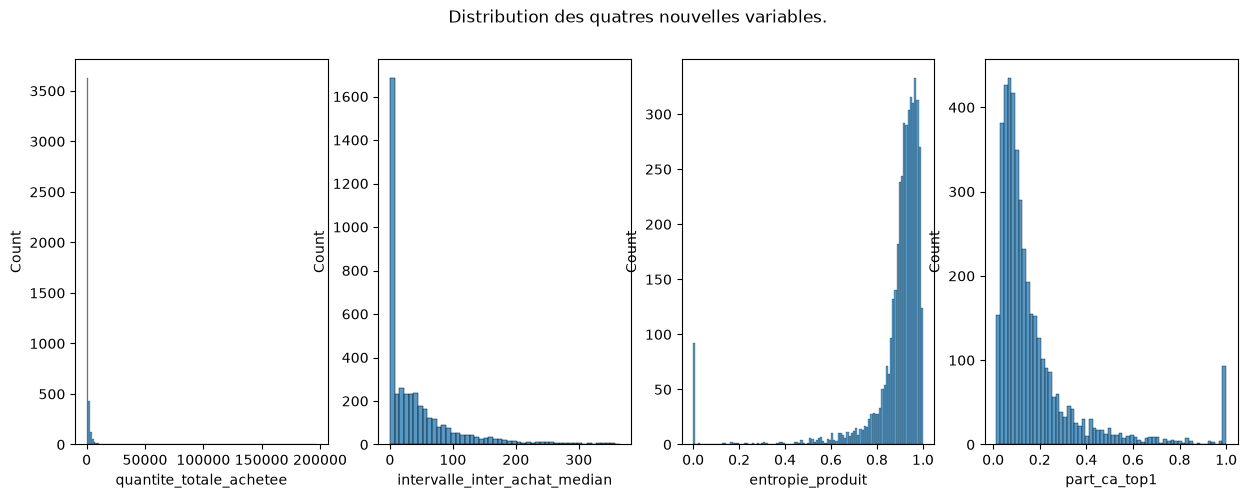

In [245]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des quatres nouvelles variables.")
sns.histplot(data, x="quantite_totale_achetee", ax=ax[0])
sns.histplot(data, x="intervalle_inter_achat_median", ax=ax[1])
sns.histplot(data, x="entropie_produit", ax=ax[2])
sns.histplot(data, x="part_ca_top1", ax=ax[3])
plt.show()

Là encore on a des distribution non centré. On appliqué un logarithme.

In [246]:
data_log = data.copy()


data_log[
    data_log.select_dtypes(include="number").columns.difference(["ancienneté"])
] = np.log1p(
    data_log[
        data_log.select_dtypes(include="number").columns.difference(["ancienneté"])
    ]
)
data_log

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1
CustomerID,,,,,,,,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000,326,11.253955,0.693147,11.214735,0.000000,0.000000,0.693147
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541,367,6.424406,3.295837,7.807510,4.077537,0.644533,0.082723
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059,358,6.109936,2.047693,7.758761,4.262680,0.628611,0.182577
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000,19,7.472245,4.304065,6.448889,0.000000,0.646261,0.157595
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000,310,5.815324,2.890372,5.288267,0.000000,0.682326,0.112987
...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000,278,5.201806,2.397895,3.828641,0.000000,0.689834,0.123305
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000,181,4.404522,2.079442,4.007333,0.000000,0.658597,0.190393
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200,126,4.500087,1.945910,4.644391,4.779123,0.677892,0.133847


In [247]:
data_log["ratio_activite_recente_historique"] = np.log1p(
    data_log["ratio_activite_recente_historique"]
)

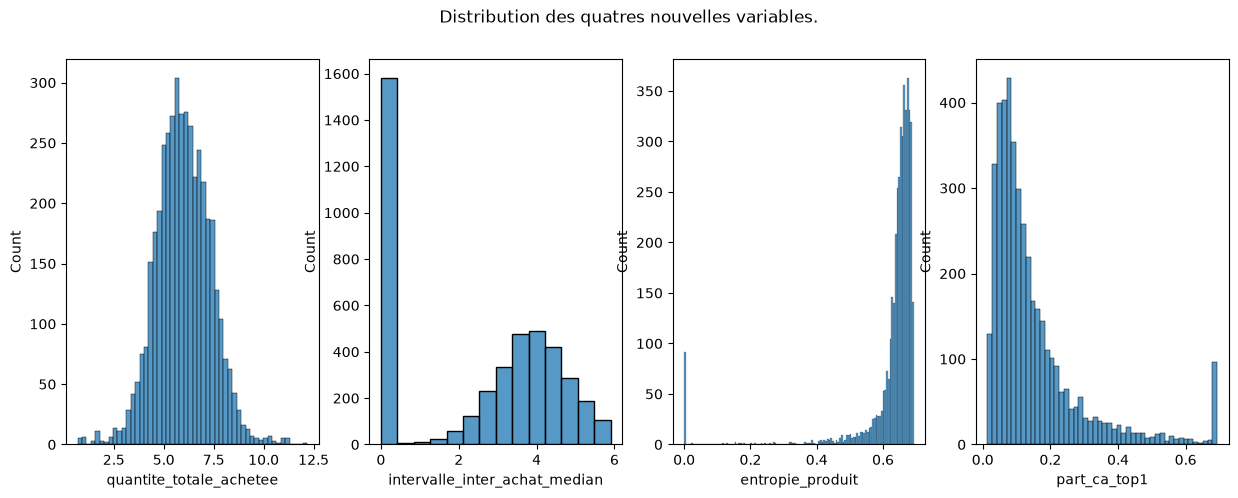

In [248]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des quatres nouvelles variables.")
sns.histplot(data_log, x="quantite_totale_achetee", ax=ax[0])
sns.histplot(data_log, x="intervalle_inter_achat_median", ax=ax[1])
sns.histplot(data_log, x="entropie_produit", ax=ax[2])
sns.histplot(data_log, x="part_ca_top1", ax=ax[3])
plt.show()

On voit que le logaritme n'est pas utile pour l'entropie. On va donc l'exclure du logarithme.

In [249]:
data_log = data.copy()


data_log[
    data_log.select_dtypes(include="number").columns.difference(
        ["ancienneté", "entropie_produit"]
    )
] = np.log1p(
    data_log[
        data_log.select_dtypes(include="number").columns.difference(
            ["ancienneté", "entropie_produit"]
        )
    ]
)
data_log

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1
CustomerID,,,,,,,,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000,326,11.253955,0.693147,11.214735,0.000000,0.000000,0.693147
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541,367,6.424406,3.295837,7.807510,4.077537,0.905097,0.082723
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059,358,6.109936,2.047693,7.758761,4.262680,0.875004,0.182577
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000,19,7.472245,4.304065,6.448889,0.000000,0.908391,0.157595
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000,310,5.815324,2.890372,5.288267,0.000000,0.978473,0.112987
...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000,278,5.201806,2.397895,3.828641,0.000000,0.993384,0.123305
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000,181,4.404522,2.079442,4.007333,0.000000,0.932080,0.190393
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200,126,4.500087,1.945910,4.644391,4.779123,0.969720,0.133847


In [250]:
data_log["ratio_activite_recente_historique"] = np.log1p(
    data_log["ratio_activite_recente_historique"]
)

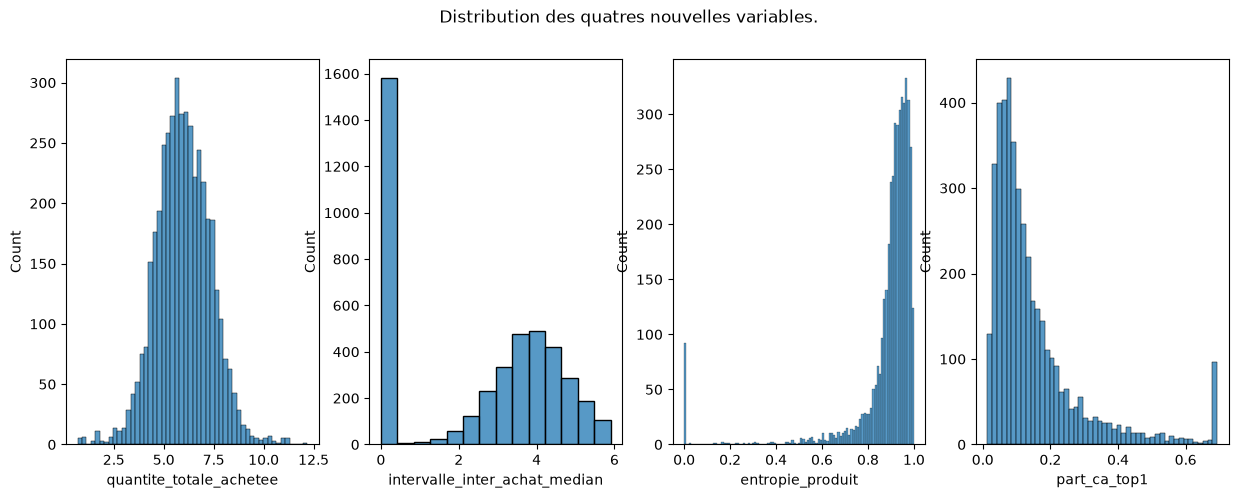

In [251]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des quatres nouvelles variables.")
sns.histplot(data_log, x="quantite_totale_achetee", ax=ax[0])
sns.histplot(data_log, x="intervalle_inter_achat_median", ax=ax[1])
sns.histplot(data_log, x="entropie_produit", ax=ax[2])
sns.histplot(data_log, x="part_ca_top1", ax=ax[3])
plt.show()

In [252]:
data_pca = PCA(n_components=3, random_state=42).fit_transform(
    StandardScaler().fit_transform(data_log)
)
data_pca

,pca0,pca1,pca2
CustomerID,,,
12346.0,0.124983,-5.046624,10.369804
12347.0,3.482024,-0.802515,0.275396
12348.0,0.983677,-1.416716,0.406682
12349.0,0.680325,2.405041,2.862492
12350.0,-1.505036,1.245299,0.233825
...,...,...,...
18280.0,-2.644162,1.007081,-0.676868
18281.0,-3.548303,0.511543,-1.096930
18282.0,-1.025787,-0.716269,-2.413778


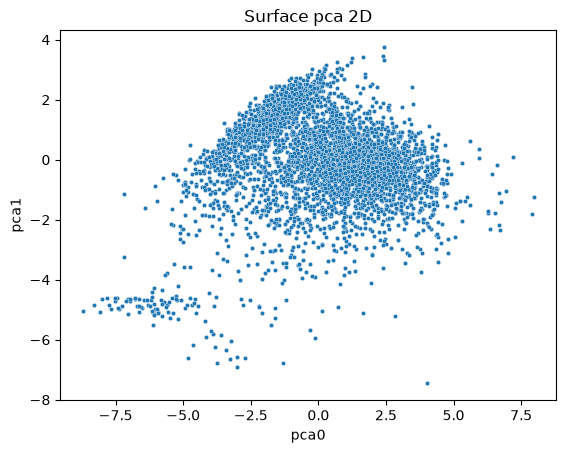

In [253]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10)
plt.title("Surface pca 2D")
plt.show()

In [254]:
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2")
fig.update_traces(marker_size=2)
fig.show()

On voit clairement qu'on peut fairee trois groupes. Essayons les algorithmes.

In [255]:
cluster = KMeans(n_clusters=3, random_state=42).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster)
fig.update_traces(marker_size=2)
fig.show()

In [256]:
cluster_spectral = SpectralClustering(
    n_clusters=3, random_state=42, gamma=0.5
).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster_spectral)
fig.update_traces(marker_size=2)
fig.show()

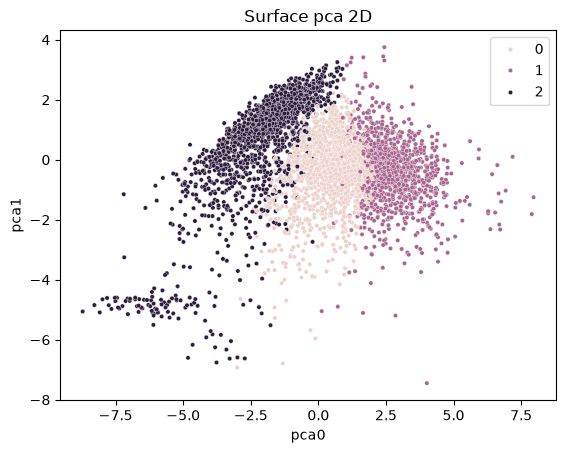

In [257]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10, hue=cluster)
plt.title("Surface pca 2D")
plt.show()

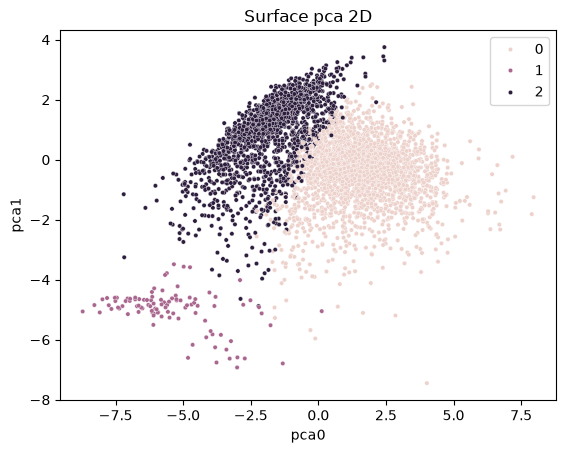

In [258]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10, hue=cluster_spectral)
plt.title("Surface pca 2D")
plt.show()

On voit que Kmeans n'arrive toujours pas à séparer les trois clusters mais le spectral clustering même si il fait encore beaucoup d'erreur, le résultats est mieux. Rajoutons encore de l'information.

On ajoute la régularité, la structure des paniers et l’évolution monétaire :

| Bloc      | Variables ajoutées                         |
| --------- | ------------------------------------------ |
| Temps     | `score_regularite`                         |
| Panier    | `part_paniers_mono_produit`                |
| Dynamique | `pente_depense`, `volatilite_mensuelle_ca` |


In [259]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

commandes = (
    df.groupby(["CustomerID", "InvoiceNo"])
    .agg(
        date_commande=("InvoiceDate", "min"),
        montant_commande=("montant_total_transaction", "sum"),
        nb_references=("StockCode", "nunique"),
    )
    .reset_index()
    .sort_values(["CustomerID", "date_commande"])
)

commandes["intervalle_jours"] = (
    commandes.groupby("CustomerID")["date_commande"]
    .diff()
    .dt.total_seconds()
    .div(86_400)
)

statistiques_intervalles = commandes.groupby("CustomerID")["intervalle_jours"].agg(
    intervalle_moyen="mean", ecart_type_intervalles="std", nb_intervalles="count"
)

coefficient_variation_intervalles = (
    statistiques_intervalles["ecart_type_intervalles"]
    / statistiques_intervalles["intervalle_moyen"]
)

score_regularite = (1 / (1 + coefficient_variation_intervalles)).rename(
    "score_regularite"
)

# Au moins deux intervalles, donc trois commandes,
# sont nécessaires pour évaluer correctement la régularité.
data["score_regularite"] = score_regularite.where(
    (statistiques_intervalles["nb_intervalles"] >= 2)
    & (statistiques_intervalles["intervalle_moyen"] > 0)
)
data.fillna(0, inplace=True)

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite
CustomerID,,,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000,1.000000,0.000000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097,0.086241,0.767788
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004,0.200307,0.573987
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391,0.170692,0.000000
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473,0.119617,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384,0.131229,0.000000
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080,0.209725,0.000000
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720,0.143218,0.000000


In [260]:
commandes["panier_mono_produit"] = commandes["nb_references"].eq(1)

data["part_paniers_mono_produit"] = (
    commandes.groupby("CustomerID")["panier_mono_produit"]
    .mean()
    .rename("part_paniers_mono_produit")
)
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite,part_paniers_mono_produit
CustomerID,,,,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000,1.000000,0.000000,1.000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097,0.086241,0.767788,0.000
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004,0.200307,0.573987,0.000
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391,0.170692,0.000000,0.000
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473,0.119617,0.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384,0.131229,0.000000,0.000
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080,0.209725,0.000000,0.000
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720,0.143218,0.000000,0.000


In [261]:
commandes["mois"] = commandes["date_commande"].dt.to_period("M").dt.to_timestamp()

ca_mensuel = (
    commandes.groupby(["CustomerID", "mois"])["montant_commande"]
    .sum()
    .rename("ca_mensuel")
    .reset_index()
)

dernier_mois_dataset = commandes["mois"].max()


def completer_ca_mensuel(groupe):
    serie = groupe.set_index("mois")["ca_mensuel"].sort_index()

    calendrier = pd.date_range(
        start=serie.index.min(), end=dernier_mois_dataset, freq="MS"
    )

    return serie.reindex(calendrier, fill_value=0)


def calculer_pente_depense(groupe):
    serie = completer_ca_mensuel(groupe)

    if len(serie) < 2:
        return np.nan

    x = np.arange(len(serie), dtype=float)
    y = serie.to_numpy(dtype=float)

    return np.polyfit(x, y, 1)[0]


data["pente_depense"] = (
    ca_mensuel.groupby("CustomerID")
    .apply(calculer_pente_depense)
    .rename("pente_depense")
)

data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite,part_paniers_mono_produit,pente_depense
CustomerID,,,,,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000,1.000000,0.000000,1.000,-2968.600000
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097,0.086241,0.767788,0.000,-1.231703
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004,0.200307,0.573987,0.000,-34.604396
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391,0.170692,0.000000,0.000,-1757.550000
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473,0.119617,0.000000,0.000,-15.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384,0.131229,0.000000,0.000,-9.850909
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080,0.209725,0.000000,0.000,-8.659286
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720,0.143218,0.000000,0.000,-4.474000


In [262]:
def calculer_volatilite_ca(groupe):
    serie = completer_ca_mensuel(groupe)

    if len(serie) < 2:
        return np.nan

    return serie.std(ddof=1)


volatilite_mensuelle_ca = (
    ca_mensuel.groupby("CustomerID")
    .apply(calculer_volatilite_ca)
    .rename("volatilite_mensuelle_ca")
)


def calculer_volatilite_relative(groupe):
    serie = completer_ca_mensuel(groupe)

    if len(serie) < 2 or serie.mean() == 0:
        return np.nan

    return serie.std(ddof=1) / serie.mean()


data["volatilite_relative_ca"] = (
    ca_mensuel.groupby("CustomerID")
    .apply(calculer_volatilite_relative)
    .rename("volatilite_relative_ca")
)
data

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite,part_paniers_mono_produit,pente_depense,volatilite_relative_ca
CustomerID,,,,,,,,,,,,,,,,
12346.0,77183.60,326,1,1,0.000000,326,77183.600000,1.000000,74215,0.0,0.000000,1.000000,0.000000,1.000,-2968.600000,3.464102
12347.0,4310.00,2,7,103,1.711606,367,615.714286,26.000000,2458,58.0,0.905097,0.086241,0.767788,0.000,-1.231703,1.207368
12348.0,1797.24,75,4,22,0.655427,358,449.310000,6.750000,2341,70.0,0.875004,0.200307,0.573987,0.000,-34.604396,1.903638
12349.0,1757.55,19,1,73,0.000000,19,1757.550000,73.000000,631,0.0,0.908391,0.170692,0.000000,0.000,-1757.550000,1.414214
12350.0,334.40,310,1,17,0.000000,310,334.400000,17.000000,197,0.0,0.978473,0.119617,0.000000,0.000,-15.200000,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,180.60,278,1,10,0.000000,278,180.600000,10.000000,45,0.0,0.993384,0.131229,0.000000,0.000,-9.850909,3.162278
18281.0,80.82,181,1,7,0.000000,181,80.820000,7.000000,54,0.0,0.932080,0.209725,0.000000,0.000,-8.659286,2.645751
18282.0,178.05,8,2,12,2.442506,126,89.025000,6.000000,103,118.0,0.969720,0.143218,0.000000,0.000,-4.474000,1.387202


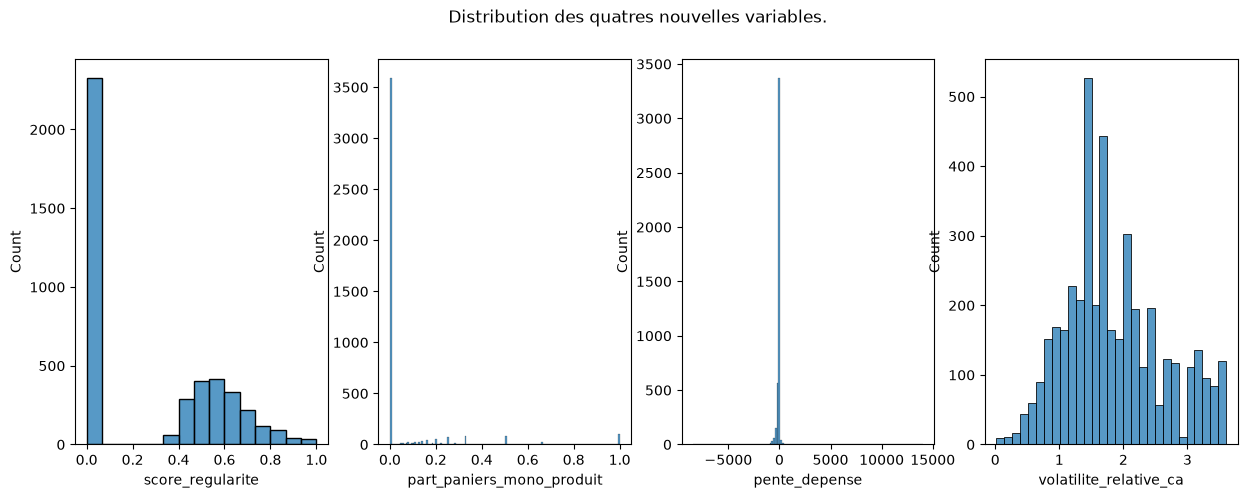

In [263]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des quatres nouvelles variables.")
sns.histplot(data, x="score_regularite", ax=ax[0])
sns.histplot(data, x="part_paniers_mono_produit", ax=ax[1])
sns.histplot(data, x="pente_depense", ax=ax[2])
sns.histplot(data, x="volatilite_relative_ca", ax=ax[3])
plt.show()

Le score de régularité et la volatilité sont tous les deux centré mais pas les deux autres variables.

In [264]:
data_log = data.copy()


data_log[
    data_log.select_dtypes(include="number").columns.difference(
        ["ancienneté", "entropie_produit", "score_regularite", "volatilite_relative_ca"]
    )
] = np.log1p(
    data_log[
        data_log.select_dtypes(include="number").columns.difference(
            [
                "ancienneté",
                "entropie_produit",
                "score_regularite",
                "volatilite_relative_ca",
            ]
        )
    ]
)
data_log.fillna(0, inplace=True)
data_log

/home/florian/Projet-Kmeans-et-spectral-clustering/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite,part_paniers_mono_produit,pente_depense,volatilite_relative_ca
CustomerID,,,,,,,,,,,,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000,326,11.253955,0.693147,11.214735,0.000000,0.000000,0.693147,0.000000,0.693147,0.000000,3.464102
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541,367,6.424406,3.295837,7.807510,4.077537,0.905097,0.082723,0.767788,0.000000,0.000000,1.207368
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059,358,6.109936,2.047693,7.758761,4.262680,0.875004,0.182577,0.573987,0.000000,0.000000,1.903638
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000,19,7.472245,4.304065,6.448889,0.000000,0.908391,0.157595,0.000000,0.000000,0.000000,1.414214
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000,310,5.815324,2.890372,5.288267,0.000000,0.978473,0.112987,0.000000,0.000000,0.000000,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000,278,5.201806,2.397895,3.828641,0.000000,0.993384,0.123305,0.000000,0.000000,0.000000,3.162278
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000,181,4.404522,2.079442,4.007333,0.000000,0.932080,0.190393,0.000000,0.000000,0.000000,2.645751
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200,126,4.500087,1.945910,4.644391,4.779123,0.969720,0.133847,0.000000,0.000000,0.000000,1.387202


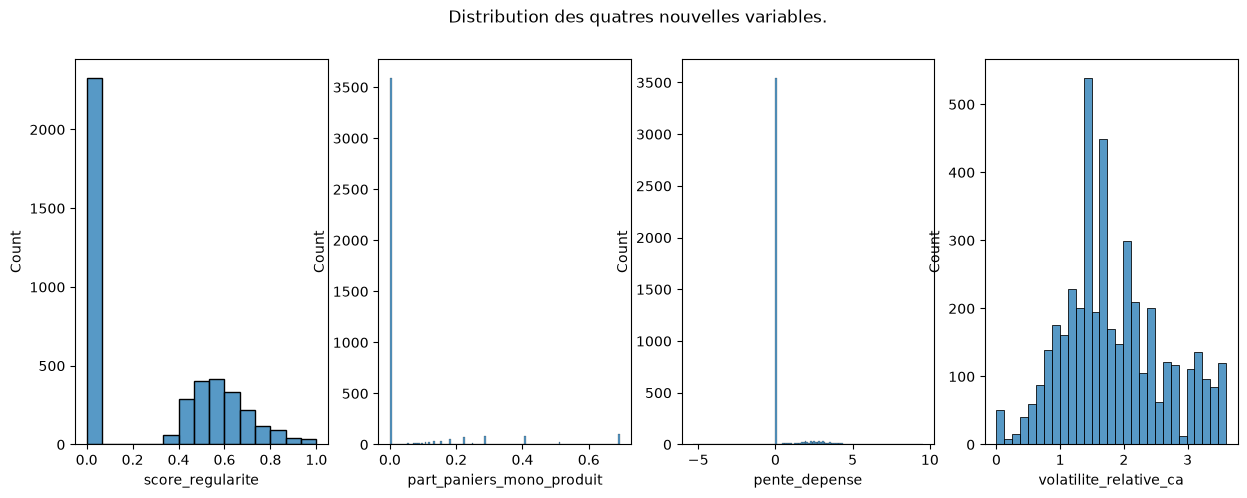

In [265]:
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(15, 5)
plt.suptitle("Distribution des quatres nouvelles variables.")
sns.histplot(data_log, x="score_regularite", ax=ax[0])
sns.histplot(data_log, x="part_paniers_mono_produit", ax=ax[1])
sns.histplot(data_log, x="pente_depense", ax=ax[2])
sns.histplot(data_log, x="volatilite_relative_ca", ax=ax[3])
plt.show()

On a réussie à centrer la pente dépense mais le logarithme n'a pratiquement rien fait à la part_paniers_mono_produit et la pente.

In [275]:
data_log = data.copy()


data_log[
    data_log.select_dtypes(include="number").columns.difference(
        [
            "ancienneté",
            "entropie_produit",
            "score_regularite",
            "volatilite_relative_ca",
            "part_paniers_mono_produit",
            "pente_depense",
        ]
    )
] = np.log1p(
    data_log[
        data_log.select_dtypes(include="number").columns.difference(
            [
                "ancienneté",
                "entropie_produit",
                "score_regularite",
                "volatilite_relative_ca",
                "part_paniers_mono_produit",
                "pente_depense",
            ]
        )
    ]
)
data_log.fillna(0, inplace=True)
data_log

,montant_total,recence,frequence,nb_produits_distincts,ratio_activite_recente_historique,ancienneté,panier_moyen,nb_refs_distinctes_moy_par_panier,quantite_totale_achetee,intervalle_inter_achat_median,entropie_produit,part_ca_top1,score_regularite,part_paniers_mono_produit,pente_depense,volatilite_relative_ca
CustomerID,,,,,,,,,,,,,,,,
12346.0,11.253955,5.789960,0.693147,0.693147,0.000000,326,11.253955,0.693147,11.214735,0.000000,0.000000,0.693147,0.000000,1.000,-2968.600000,3.464102
12347.0,8.368925,1.098612,2.079442,4.644391,0.997541,367,6.424406,3.295837,7.807510,4.077537,0.905097,0.082723,0.767788,0.000,-1.231703,1.207368
12348.0,7.494564,4.330733,1.609438,3.135494,0.504059,358,6.109936,2.047693,7.758761,4.262680,0.875004,0.182577,0.573987,0.000,-34.604396,1.903638
12349.0,7.472245,2.995732,0.693147,4.304065,0.000000,19,7.472245,4.304065,6.448889,0.000000,0.908391,0.157595,0.000000,0.000,-1757.550000,1.414214
12350.0,5.815324,5.739793,0.693147,2.890372,0.000000,310,5.815324,2.890372,5.288267,0.000000,0.978473,0.112987,0.000000,0.000,-15.200000,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,5.201806,5.631212,0.693147,2.397895,0.000000,278,5.201806,2.397895,3.828641,0.000000,0.993384,0.123305,0.000000,0.000,-9.850909,3.162278
18281.0,4.404522,5.204007,0.693147,2.079442,0.000000,181,4.404522,2.079442,4.007333,0.000000,0.932080,0.190393,0.000000,0.000,-8.659286,2.645751
18282.0,5.187665,2.197225,1.098612,2.564949,1.236200,126,4.500087,1.945910,4.644391,4.779123,0.969720,0.133847,0.000000,0.000,-4.474000,1.387202


In [276]:
data_log["ratio_activite_recente_historique"] = np.log1p(
    data_log["ratio_activite_recente_historique"]
)

In [277]:
data_pca = PCA(n_components=3, random_state=42).fit_transform(
    StandardScaler().fit_transform(data_log)
)
data_pca

,pca0,pca1,pca2
CustomerID,,,
12346.0,-1.544413,-5.446262,-4.325534
12347.0,3.924097,-0.714034,-0.064907
12348.0,1.201556,-1.157617,1.036419
12349.0,0.290253,2.845932,-3.951987
12350.0,-2.169285,1.485289,1.645519
...,...,...,...
18280.0,-3.123760,1.200342,1.513422
18281.0,-3.724592,0.615413,0.607866
18282.0,-0.898972,-0.353739,-0.487408


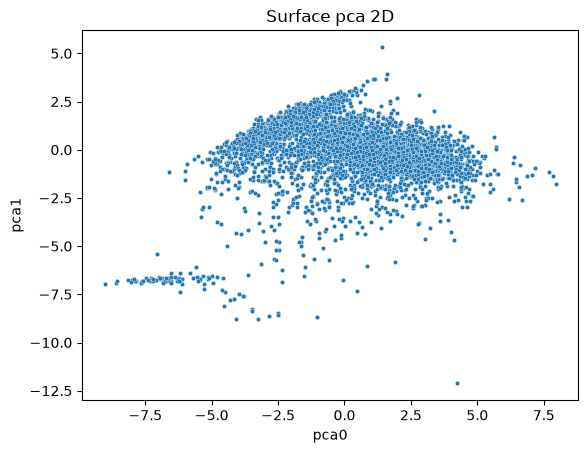

In [278]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10)
plt.title("Surface pca 2D")
plt.show()

In [280]:
cluster = KMeans(n_clusters=3, random_state=42).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster)
fig.update_traces(marker_size=2)
fig.show()

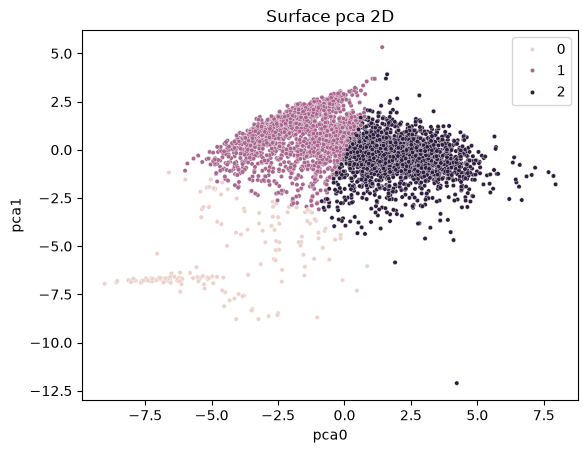

In [281]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10, hue=cluster)
plt.title("Surface pca 2D")
plt.show()

In [284]:
cluster_spectral = SpectralClustering(
    n_clusters=3, random_state=42, gamma=0.01
).fit_predict(data_pca)
fig = px.scatter_3d(data_pca, x="pca0", y="pca1", z="pca2", color=cluster_spectral)
fig.update_traces(marker_size=2)
fig.show()

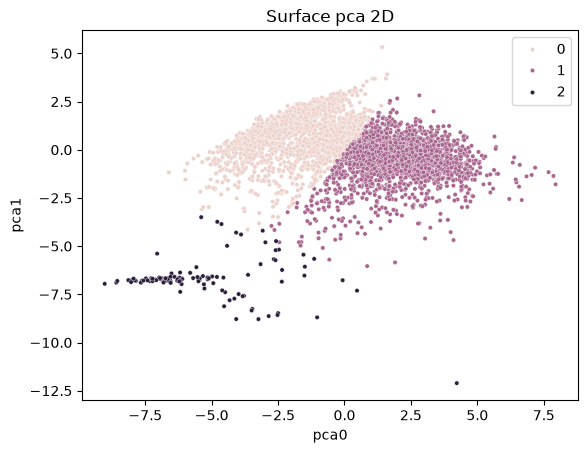

In [285]:
sns.scatterplot(data_pca, x="pca0", y="pca1", s=10, hue=cluster_spectral)
plt.title("Surface pca 2D")
plt.show()